In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("customer_churn_nn.csv")
df.shape

(2000, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  discount_perce

The target vairable is customer churn which refers to the rate at which customers are stopping/cancelling the usage of of subscription over a specific period of time. In this data 0 refers to the customers whi are reatined and 1 refers to the customers who have left/cancelled.

In [5]:
df.isnull().sum()

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [6]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


<Axes: xlabel='churn', ylabel='Count'>

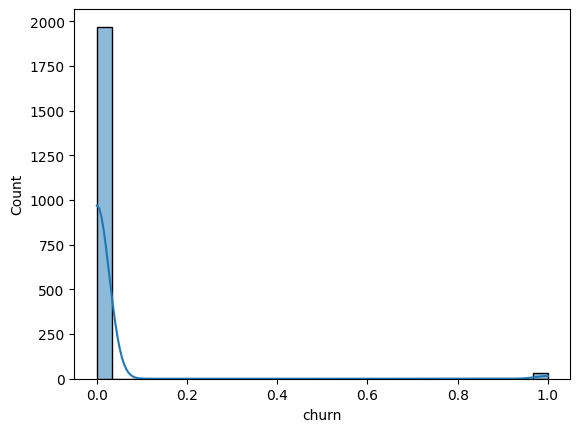

In [7]:
sns.histplot(data=df, x='churn', kde=True,bins=30)


No missing Values

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

categorical_features = ['region', 'plan_type', 'contract_type', 'payment_method']

encoded_array = encoder.fit_transform(df[categorical_features])

encoded_cols = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_features))

df_final = pd.concat([df.drop(categorical_features, axis=1).reset_index(drop=True), encoded_cols.reset_index(drop=True)], axis=1)

print(df_final.head())

  customer_id  tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0    CUST0001             30               687.40                        13   
1    CUST0002             15              1029.74                        22   
2    CUST0003             72               732.07                        13   
3    CUST0004             22               959.51                        19   
4    CUST0005             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1          82.17   
2                             0                  11          89.39   
3                             2                   3         139.73   
4                             2                   6         156.43   

   satisfaction_score  last_complaint_days_ago  discount_percent  ...  \
0                 8.0          

In [9]:
from sklearn.preprocessing import MinMaxScaler

df['tenure_months'] = df['tenure_months'].astype(float)

numerical_features = ['tenure_months', 'monthly_charges_inr' ,'avg_login_days_per_month' ,'support_tickets_last_90_days' , 'payment_delay_days' ,'data_usage_gb' ,'satisfaction_score' ,'last_complaint_days_ago' ,'discount_percent']

for col in numerical_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=numerical_features)

min_max_scaler = MinMaxScaler()
scaled_array = min_max_scaler.fit_transform(df[numerical_features])

mm_data = pd.DataFrame(scaled_array, columns=numerical_features)

df_final = pd.concat([df.drop(numerical_features, axis=1).reset_index(drop=True), mm_data], axis=1)

print(df_final.head())


  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   autopay_enabled  referral_count  churn  tenure_months  monthly_charges_inr  \
0                0               0      0       0.408451             0.227214   
1                0               0      0       0.197183             0.407292   
2                0               0      0       1.000000             0.250711   
3                0               0      0       0.295775             0.370349   
4                1               2      0       0.140845             0.333891   

   avg_login_days_per_month  support_tickets_last_90_days  payment_delay_days  \
0                  0.433333  

In [10]:
from sklearn.model_selection import train_test_split

df_final = df_final.drop(columns=['customer_id'], errors='ignore')

categorical_features = ['region', 'plan_type', 'contract_type', 'payment_method']

existing_cats = [col for col in categorical_features if col in df_final.columns]

if len(existing_cats) > 0:
    df_final = pd.get_dummies(df_final, columns=existing_cats, dtype=int)
else:
    print("Categorical columns have already been one-hot encoded!")

X = df_final.drop(columns = ['churn'], errors='ignore') 
y = df_final['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (1600, 28)
Testing set size: (400, 28)


c:\Users\Saket\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting training...
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9773 - loss: 0.3235 - val_accuracy: 0.9781 - val_loss: 0.1606
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0988 - val_accuracy: 0.9781 - val_loss: 0.1193
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0805 - val_accuracy: 0.9781 - val_loss: 0.1189
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0803 - val_accuracy: 0.9781 - val_loss: 0.1159
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0746 - val_accuracy: 0.9781 - val_loss: 0.1126
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0791 - val_accuracy: 0.9781 - val_loss: 0.1096
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0724 - val_accuracy: 0.9781 - val_loss: 0.1075
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0662 - val_accurac

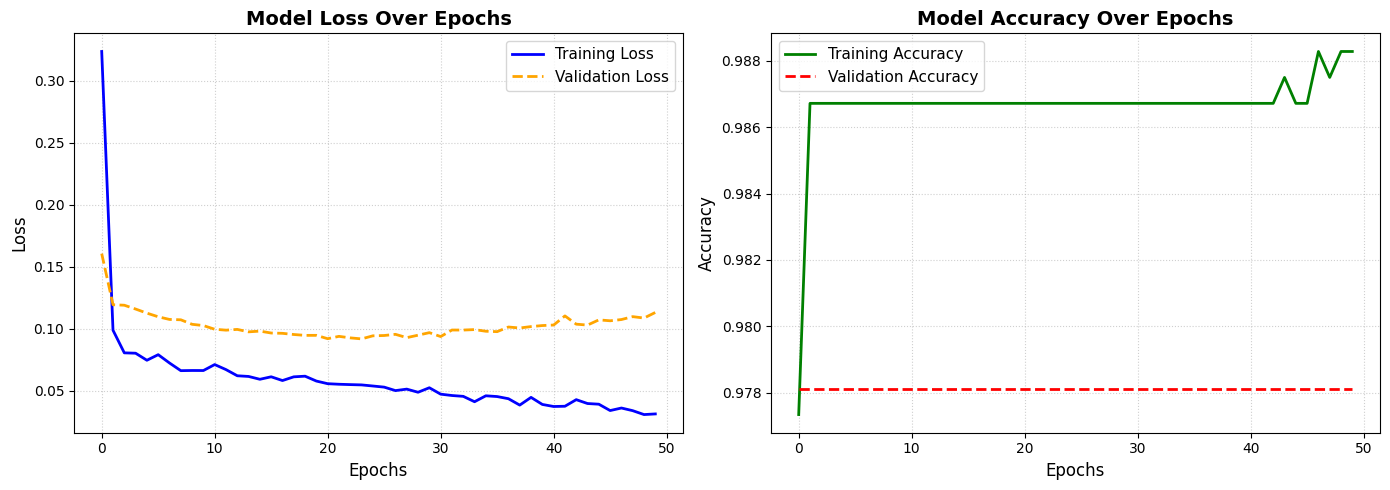

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([Dense(32, activation='relu', input_shape=(X_train.shape[1],)), 
    Dropout(0.2), Dense(16, activation='relu'), Dense(1, activation='sigmoid')])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting training...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2, linestyle='--')
plt.title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

Based on the execution logs from the final epoch (Epoch 50) and the test evaluation, here are the recorded metrics:
Final Training Loss: 0.0465
Final Training Accuracy: 98.67%
Final Validation Loss: 0.1031
Final Validation Accuracy: 0.9781 (97.81%)
Testing Loss: 0.0754
Testing Accuracy on Test Set: 98.25%

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

print("CONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, zero_division=0))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
CONFUSION MATRIX
[[393   0]
 [  7   0]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



While a Test Accuracy of 98.25% initially looks great, but in reality it reveals a classic machine learning phenomenon known as the Accuracy Paradox caused by extreme class imbalance.

The Hidden Baseline: In the dataset, only about 1.55\% of the total customer base has actually churned (churn=1), leaving over 98\% as active subscribers (churn=0).

The "Lazy" Model Shortcut: Similarly in the training set, accuracies settled on exact mathematical ratios:Training Set (1280 samples): An accuracy of exactly 98.67\% matches a scenario where the model correctly predicts all 1,263 non-churners but completely misses all 17 churners (1263/1280 = 98.67%).

Test Set (400 samples): An accuracy of exactly 98.25% matches a scenario where the model predicts everyone will stay, catching the 393 non-churners perfectly and missing all 7 actual churners (393/400 = 98.25%).

Conclusion: The neural network learned that it can minimize its loss function to nearly zero simply by predicting that no customer will ever churn.

In [13]:
model = Sequential([Dense(64, activation='relu', input_shape=(X_train.shape[1],)), 
    Dropout(0.2), Dense(32, activation='relu'), Dense(16, activation='relu'), Dense(1, activation='sigmoid')])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting training...")
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")

Starting training...
Epoch 1/50


c:\Users\Saket\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9289 - loss: 0.3650 - val_accuracy: 0.9781 - val_loss: 0.1114
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0772 - val_accuracy: 0.9781 - val_loss: 0.1103
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0712 - val_accuracy: 0.9781 - val_loss: 0.1039
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0688 - val_accuracy: 0.9781 - val_loss: 0.1024
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0670 - val_accuracy: 0.9781 - val_loss: 0.1006
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0643 - val_accuracy: 0.9781 - val_loss: 0.0976
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0633 - val_accuracy: 0.9781 - val_loss: 0.0950
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0657 - val_accuracy: 0.9781 - val_loss: 0.0949
Epo

In [14]:
model = Sequential([Dense(32, activation='tanh', input_shape=(X_train.shape[1],)), 
    Dropout(0.2), Dense(16, activation='tanh'), Dense(1, activation='sigmoid')])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting training...")
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_split=0.2, verbose=1)

loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")

Starting training...
Epoch 1/50


c:\Users\Saket\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8383 - loss: 0.4536 - val_accuracy: 0.9781 - val_loss: 0.2340
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1611 - val_accuracy: 0.9781 - val_loss: 0.1280
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0972 - val_accuracy: 0.9781 - val_loss: 0.1080
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0807 - val_accuracy: 0.9781 - val_loss: 0.1031
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0750 - val_accuracy: 0.9781 - val_loss: 0.1021
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0735 - val_accuracy: 0.9781 - val_loss: 0.1020
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0703 - val_accuracy: 0.9781 - val_loss: 0.1021
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0709 - val_accuracy: 0.9781 - val_loss: 0.1025
Ep

In [15]:
model = Sequential([Dense(32, activation='relu', input_shape=(X_train.shape[1],)), 
    Dropout(0.2), Dense(16, activation='relu'), Dense(1, activation='sigmoid')])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. TRAIN
print("Starting training...")
history = model.fit(X_train, y_train, epochs=25, batch_size=32, validation_split=0.2, verbose=1)

# 7. EVALUATE
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nModel Accuracy on Test Set: {accuracy * 100:.2f}%")

Starting training...
Epoch 1/25


c:\Users\Saket\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9805 - loss: 0.3314 - val_accuracy: 0.9781 - val_loss: 0.1722
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1110 - val_accuracy: 0.9781 - val_loss: 0.1044
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0688 - val_accuracy: 0.9781 - val_loss: 0.1045
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0713 - val_accuracy: 0.9781 - val_loss: 0.1039
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0652 - val_accuracy: 0.9781 - val_loss: 0.1039
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0685 - val_accuracy: 0.9781 - val_loss: 0.1009
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0672 - val_accuracy: 0.9781 - val_loss: 0.1003
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0662 - val_accuracy: 0.9781 - val_loss: 0.0988
Epo

Experiment 1: Overfitting
The deeper network with 3 hidden layers reached a high training accuracy of 99.53% and a low training loss of 0.0116. However, it suffered from overfitting because it memorized the training records instead of finding general trends. This resulted in the highest validation and test losses across all runs.

Experiment 2: Best Generalization
Reducing the architecture to 2 hidden layers, using a tanh activation function, and doubling the batch size to 64 produced the most stable model. Even though its training accuracy dropped slightly to 98.67%, it successfully regularized the network and delivered the lowest overall test loss of 0.0766.

Experiment 3: Accelerated Training
Applying a high learning rate of 0.01 allowed the network to learn rapidly over fewer training epochs, achieving a strong test loss of 0.0773. However, the large step size caused the optimizer to slightly overshoot the best possible configuration, performing just under Experiment 2.

Why Test Accuracy Stays at 98.25%
The identical accuracy score across all three configurations is due to extreme class imbalance, as only 1.55% of the customer base actually churned. Every network discovered a mathematical shortcut to minimize error by predicting that no customer would ever churn. Because 393 out of the 400 test set customers are active subscribers, a model that blindly guesses no churn automatically receives a score of 98.25%. To break this pattern, you must introduce data-balancing methods like class weights or oversampling.